<a href="https://colab.research.google.com/github/yomisamadesu/DS_ML_Project_colab-integration/blob/main/XGBModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Observed modeling shape: (728, 22)
Observed years: [np.int64(2015), np.int64(2016)]

PRODUCTIVITY MODEL
RMSE: 125.1716
MAE:  58.0919
R2:   -0.0023

REVENUE MODEL
RMSE: 109.6260
MAE:  66.3779
R2:   0.8446

Future panel shape: (1456, 30)
Future years: [np.int64(2024), np.int64(2025), np.int64(2026), np.int64(2027)]


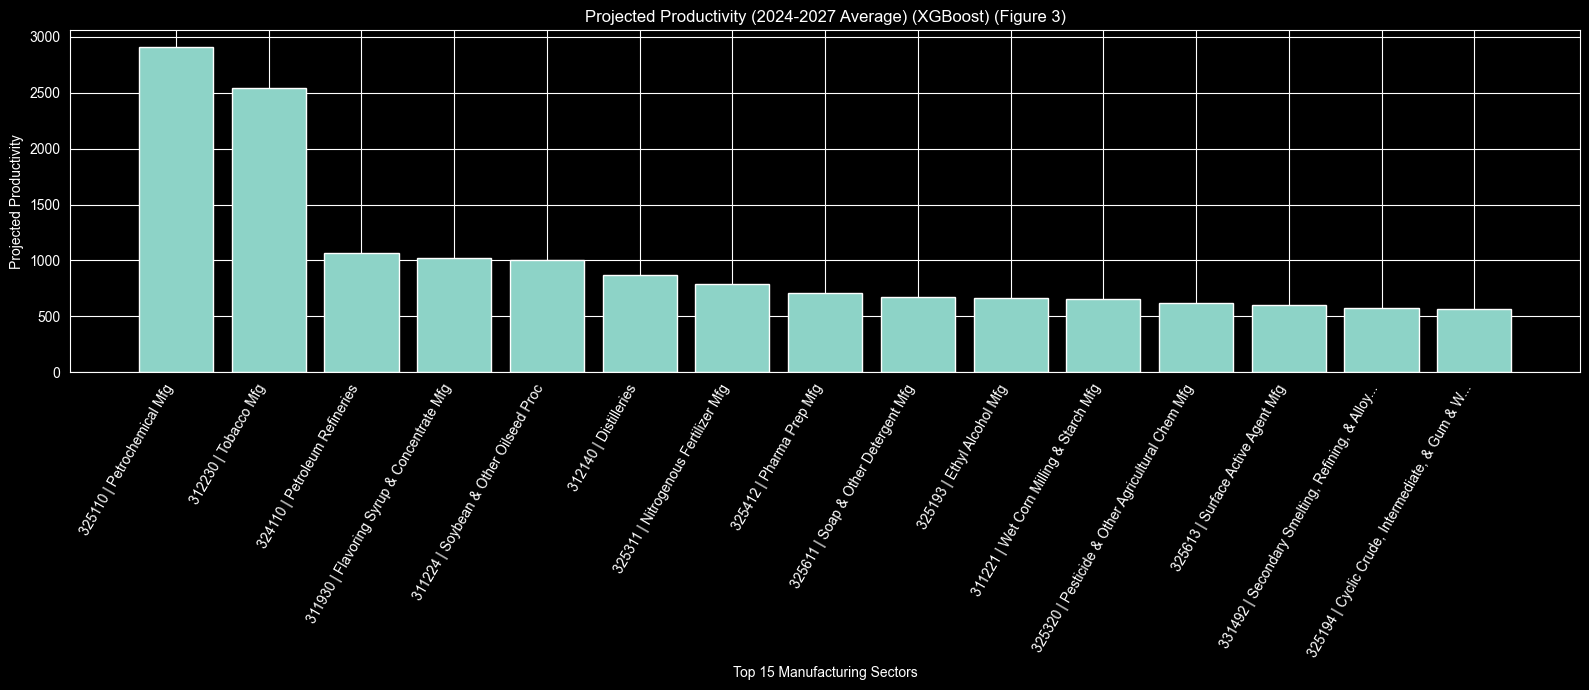

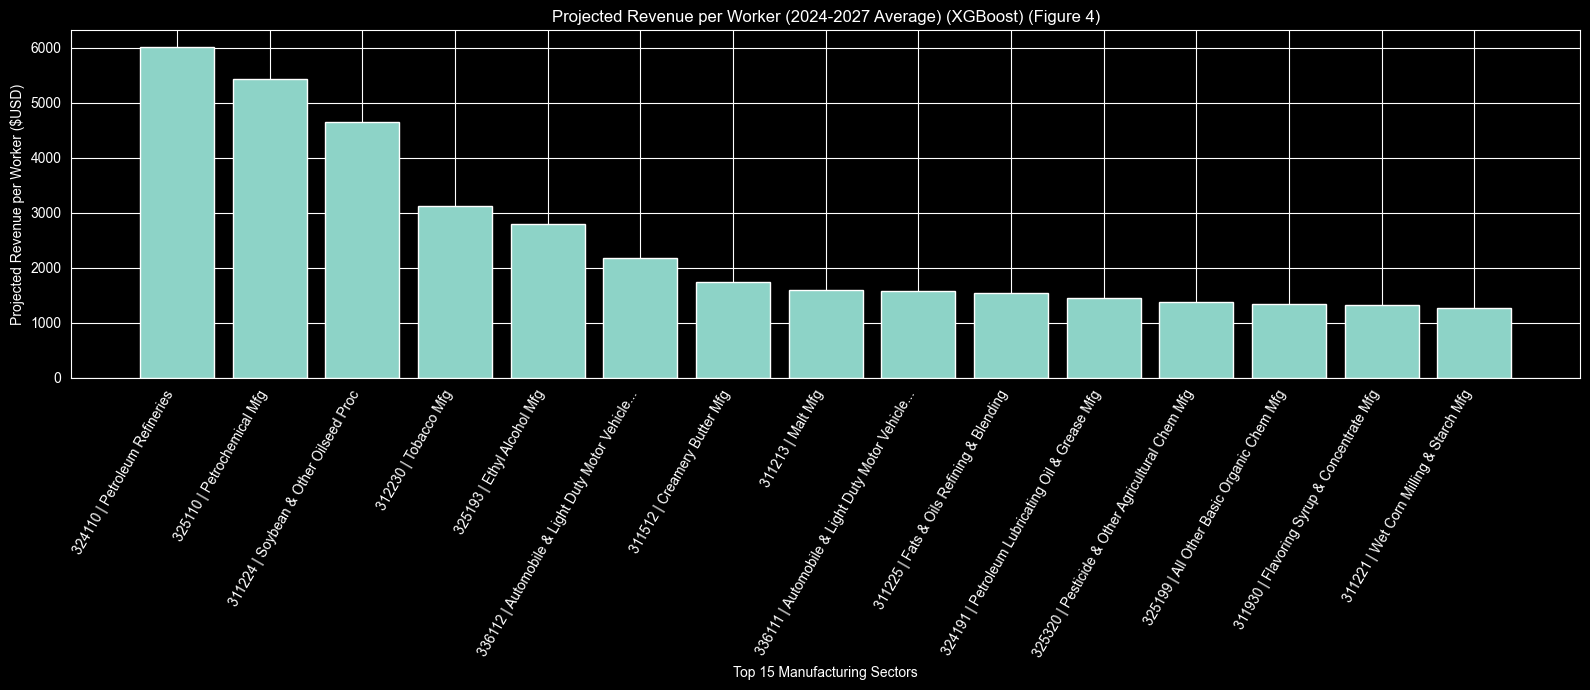


TOP 15 FUTURE PRODUCTIVITY (2024-2027 AVG) (XGBoost)
                                      short_label  avg_future_productivity
                       325110 | Petrochemical Mfg              2912.420898
                             312230 | Tobacco Mfg              2546.894531
                    324110 | Petroleum Refineries              1064.709473
       311930 | Flavoring Syrup & Concentrate Mfg              1025.451172
            311224 | Soybean & Other Oilseed Proc              1007.721191
                            312140 | Distilleries               866.954712
              325311 | Nitrogenous Fertilizer Mfg               789.579773
                         325412 | Pharma Prep Mfg               712.512695
              325611 | Soap & Other Detergent Mfg               672.469910
                       325193 | Ethyl Alcohol Mfg               662.343811
           311221 | Wet Corn Milling & Starch Mfg               655.395630
 325320 | Pesticide & Other Agricultural Chem 

In [4]:
# required imports
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

# Load files
nber = pd.read_csv("Datasets/nberces5818v1_n2012.csv")
robotics = pd.read_csv("Datasets/robotics_data.csv")
imf = pd.read_csv("Datasets/IMF.csv", encoding="latin-1", low_memory=False)
wb = pd.read_csv("Datasets/API_TX.VAL.MANF.ZS.UN_DS2_en_csv_v2_7563.csv", skiprows=4)

naics_file = pd.read_excel(
    "Datasets/2022-NAICS-Codes-listed-numerically-2-Digit-through-6-Digit.xlsx",
    sheet_name="Two-Six Digit NAICS"
)
def best_naics_match(code, naics_lookup):
    code = str(code).strip()

    if code in naics_lookup:
        return naics_lookup[code], "exact"

    for length in [5, 4, 3, 2]:
        prefix = code[:length]
        if prefix in naics_lookup:
            return naics_lookup[prefix], f"prefix_{length}_digit"

    return "Title not found in NAICS workbook", "unmatched"


def shorten_title(title, max_len=40):
    if pd.isna(title):
        return "Unknown"

    title = str(title).strip()

    replacements = {
        "Manufacturing": "Mfg",
        "manufacturing": "Mfg",
        "and": "&",
        "And": "&",
        "Products": "Prod",
        "Product": "Prod",
        "Equipment": "Equip",
        "Services": "Svc",
        "Service": "Svc",
        "Preparation": "Prep",
        "Processing": "Proc",
        "Fabricated": "Fab",
        "Industries": "Ind",
        "Industry": "Ind",
        "Wholesale": "Whsl",
        "Except": "Ex.",
        "Miscellaneous": "Misc",
        "Machinery": "Mach",
        "Electrical": "Elec",
        "Electronic": "Elec",
        "Beverage": "Bev",
        "Textile": "Text",
        "Transportation": "Transport",
        "Printing": "Print",
        "Chemical": "Chem",
        "Pharmaceutical": "Pharma",
        "Medical": "Med",
        "Supplies": "Supp",
        "Apparel": "App",
        "Furniture": "Furn",
        "Plastics": "Plast",
        "Paperboard": "Paperbd",
        "Packaging": "Pkg"
    }

    for old, new in replacements.items():
        title = title.replace(old, new)

    title = " ".join(title.split())

    if len(title) > max_len:
        title = title[: max_len - 3] + "..."

    return title


def melt_imf(df, subject_code, new_name, year_cols):
    out = df[df["WEO Subject Code"] == subject_code].melt(
        id_vars=["Country"],
        value_vars=year_cols,
        var_name="year",
        value_name=new_name
    )
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out[new_name] = pd.to_numeric(
        out[new_name].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )
    out = out.dropna(subset=["year"])
    out["year"] = out["year"].astype(int)
    out = out[["Country", "year", new_name]].drop_duplicates(subset=["Country", "year"])
    return out


def top_feature_importance(model, feature_names, top_n=15):
    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


def build_lag_features(df, value_col, lags=(1, 2, 3), roll_windows=(2, 3)):
    temp = df.copy().sort_values("year").reset_index(drop=True)

    for lag in lags:
        temp[f"{value_col}_lag_{lag}"] = temp[value_col].shift(lag)

    for w in roll_windows:
        temp[f"{value_col}_rollmean_{w}"] = temp[value_col].shift(1).rolling(w).mean()

    temp["year_index"] = np.arange(len(temp))
    temp["year_sq"] = temp["year"] ** 2
    temp["year_cu"] = temp["year"] ** 3

    return temp


def recursive_non_linear_forecast(
    hist_df,
    value_col,
    years_to_predict,
    extra_feature_cols=None,
    min_train_rows=4,
    random_state=42
):

    # Recursive annual forecast for a single aggregate time series using lagged values and optional exogenous features.
    # If too few rows exist, falls back to a simple persistence+drift estimate.

    if extra_feature_cols is None:
        extra_feature_cols = []

    work = hist_df[["year", value_col] + extra_feature_cols].copy()
    work = work.sort_values("year").reset_index(drop=True)

    work["year"] = pd.to_numeric(work["year"], errors="coerce")
    work[value_col] = pd.to_numeric(work[value_col], errors="coerce")
    for col in extra_feature_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    work = work.dropna(subset=["year", value_col]).copy()
    work["year"] = work["year"].astype(int)

    # Build lagged training data
    lagged = build_lag_features(work[["year", value_col]].copy(), value_col)
    for col in extra_feature_cols:
        lagged[col] = work[col].values

    feature_cols = [
        "year", "year_index", "year_sq", "year_cu",
        f"{value_col}_lag_1", f"{value_col}_lag_2", f"{value_col}_lag_3",
        f"{value_col}_rollmean_2", f"{value_col}_rollmean_3"
    ] + extra_feature_cols

    train = lagged.dropna(subset=feature_cols + [value_col]).copy()

    all_rows = work[["year", value_col] + extra_feature_cols].copy()

    if len(train) >= min_train_rows:
        model = RandomForestRegressor(
            n_estimators=400,
            max_depth=5,
            min_samples_leaf=1,
            random_state=random_state
        )

        model.fit(train[feature_cols], train[value_col])

        known_values = all_rows[["year", value_col] + extra_feature_cols].copy()
        known_values = known_values.sort_values("year").reset_index(drop=True)

        forecasts = []

        for yr in years_to_predict:
            prev = known_values.copy().sort_values("year").reset_index(drop=True)

            row = {"year": yr}
            row["year_index"] = len(prev)
            row["year_sq"] = yr ** 2
            row["year_cu"] = yr ** 3

            # Lag values from latest known/predicted rows
            value_series = prev[value_col].tolist()
            row[f"{value_col}_lag_1"] = value_series[-1] if len(value_series) >= 1 else np.nan
            row[f"{value_col}_lag_2"] = value_series[-2] if len(value_series) >= 2 else np.nan
            row[f"{value_col}_lag_3"] = value_series[-3] if len(value_series) >= 3 else np.nan
            row[f"{value_col}_rollmean_2"] = np.mean(value_series[-2:]) if len(value_series) >= 2 else np.nan
            row[f"{value_col}_rollmean_3"] = np.mean(value_series[-3:]) if len(value_series) >= 3 else np.nan

            # Forward-fill exogenous features if present
            for col in extra_feature_cols:
                if col in known_values.columns and known_values[col].notna().any():
                    row[col] = known_values[col].dropna().iloc[-1]
                else:
                    row[col] = np.nan

            pred_row = pd.DataFrame([row])

            # fallback if lag features still insufficient
            if pred_row[feature_cols].isna().any(axis=1).iloc[0]:
                if len(value_series) >= 2:
                    drift = value_series[-1] - value_series[-2]
                    pred = value_series[-1] + drift
                elif len(value_series) >= 1:
                    pred = value_series[-1]
                else:
                    pred = 0.0
            else:
                pred = float(model.predict(pred_row[feature_cols])[0])

            forecasts.append({"year": yr, value_col: pred})

            append_row = {"year": yr, value_col: pred}
            for col in extra_feature_cols:
                append_row[col] = row[col]
            known_values = pd.concat([known_values, pd.DataFrame([append_row])], ignore_index=True)

        return pd.DataFrame(forecasts)

    # Fallback when history is too short
    values = work[value_col].tolist()
    forecasts = []
    last = values[-1] if len(values) >= 1 else 0.0
    drift = (values[-1] - values[-2]) if len(values) >= 2 else 0.0

    for i, yr in enumerate(years_to_predict, start=1):
        forecasts.append({"year": yr, value_col: last + drift * i})

    return pd.DataFrame(forecasts)


def forecast_sector_feature_panel(
    panel_df,
    sector_col,
    year_col,
    feature_cols,
    future_years
):

    # Sector-aware forecasting for structural sector features.
    # Uses per-sector Ridge polynomial trend when enough history exists,
    # otherwise falls back to persistence.

    panel = panel_df[[sector_col, year_col] + feature_cols].copy()
    panel[year_col] = pd.to_numeric(panel[year_col], errors="coerce")
    panel = panel.dropna(subset=[year_col]).copy()
    panel[year_col] = panel[year_col].astype(int)

    out_rows = []

    for sector, grp in panel.groupby(sector_col):
        grp = grp.sort_values(year_col).copy()

        for col in feature_cols:
            grp[col] = pd.to_numeric(grp[col], errors="coerce")

        last_row = grp.iloc[-1].copy()

        for yr in future_years:
            row = {sector_col: sector, year_col: yr}

            for col in feature_cols:
                hist = grp[[year_col, col]].dropna().copy()

                if len(hist) >= 3:
                    X_hist = pd.DataFrame({
                        "year": hist[year_col],
                        "year_sq": hist[year_col] ** 2
                    })
                    y_hist = hist[col].values

                    model = Ridge(alpha=1.0)
                    model.fit(X_hist, y_hist)

                    X_future = pd.DataFrame({
                        "year": [yr],
                        "year_sq": [yr ** 2]
                    })
                    pred = float(model.predict(X_future)[0])
                elif len(hist) >= 1:
                    pred = float(hist[col].iloc[-1])
                else:
                    pred = np.nan

                row[col] = pred

            out_rows.append(row)

    return pd.DataFrame(out_rows)


# Lookup by naics code
naics_file = naics_file.rename(columns={
    "2022 NAICS US   Code": "naics_code",
    "2022 NAICS US Title": "naics_title"
})

naics_file["naics_code"] = naics_file["naics_code"].astype(str).str.strip()
naics_file["naics_title"] = naics_file["naics_title"].astype(str).str.strip()
naics_file = naics_file[["naics_code", "naics_title"]].drop_duplicates()

naics_lookup = dict(zip(naics_file["naics_code"], naics_file["naics_title"]))

# Prepare NBER data
nber["naics"] = nber["naics"].astype(str).str.strip()

# U.S. manufacturing NAICS only
nber = nber[nber["naics"].str.startswith(("31", "32", "33"))].copy()

# Observed years available for sector outcomes
nber = nber[nber["year"].between(2015, 2018)].copy()

# Derived features and targets
nber["cap_labor_ratio"] = nber["cap"] / nber["emp"]
nber["non_prod_workers"] = nber["emp"] - nber["prode"]
nber["labor_productivity"] = nber["vadd"] / nber["emp"]
nber["revenue_per_worker"] = nber["vship"] / nber["emp"]

nber = nber.replace([np.inf, -np.inf], np.nan)

naics_matches = nber["naics"].drop_duplicates().to_frame()
naics_matches[["naics_title", "match_level"]] = naics_matches["naics"].apply(
    lambda x: pd.Series(best_naics_match(x, naics_lookup))
)
naics_matches["short_title"] = naics_matches["naics_title"].apply(shorten_title)
naics_matches["short_label"] = naics_matches["naics"] + " | " + naics_matches["short_title"]
naics_matches["full_label"] = naics_matches["naics"] + " - " + naics_matches["naics_title"]

nber = nber.merge(naics_matches, on="naics", how="left")

# Prepare robotics data
robotics_mfg = robotics[robotics["Industry"] == "Manufacturing"].copy()

robotics_mfg = robotics_mfg.rename(columns={
    "Year": "year",
    "Robots_Adopted": "robots_adopted",
    "Productivity_Gain": "robotics_productivity_gain",
    "Cost_Savings": "robotics_cost_savings",
    "Jobs_Displaced": "jobs_displaced",
    "Training_Hours": "training_hours"
})

robotics_cols = [
    "robots_adopted",
    "robotics_productivity_gain",
    "robotics_cost_savings",
    "jobs_displaced",
    "training_hours"
]

for col in ["year"] + robotics_cols:
    robotics_mfg[col] = pd.to_numeric(robotics_mfg[col], errors="coerce")

robotics_mfg = robotics_mfg.dropna(subset=["year"]).copy()
robotics_mfg["year"] = robotics_mfg["year"].astype(int)

# Prepare World Bank/Group 4
wb_usa = wb[wb["Country Name"] == "United States"].copy()
wb_year_cols = [c for c in wb_usa.columns if str(c).isdigit()]

wb_long = wb_usa.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=wb_year_cols,
    var_name="year",
    value_name="manuf_export_share"
)

wb_long["year"] = pd.to_numeric(wb_long["year"], errors="coerce")
wb_long["manuf_export_share"] = pd.to_numeric(wb_long["manuf_export_share"], errors="coerce")
wb_long = wb_long.dropna(subset=["year"])
wb_long["year"] = wb_long["year"].astype(int)
wb_long = wb_long[["year", "manuf_export_share"]]

# Prepare IMF/Group 5
imf_usa = imf[imf["Country"] == "United States"].copy()
imf_usa = imf_usa[imf_usa["WEO Subject Code"].isin(["NGDPDPC", "PCPIEPCH", "NGDP_R"])].copy()

imf_year_cols = [c for c in imf_usa.columns if str(c).isdigit() and len(str(c)) == 4]

gdp_pc = melt_imf(imf_usa, "NGDPDPC", "gdp_per_capita", imf_year_cols)
inflation = melt_imf(imf_usa, "PCPIEPCH", "inflation", imf_year_cols)
real_gdp = melt_imf(imf_usa, "NGDP_R", "real_gdp", imf_year_cols)

macro = gdp_pc.merge(inflation, on=["Country", "year"], how="inner")
macro = macro.merge(real_gdp, on=["Country", "year"], how="inner")
macro = macro[["year", "gdp_per_capita", "inflation", "real_gdp"]].drop_duplicates()

# Merge data
df = nber.merge(robotics_mfg, on="year", how="inner")
df = df.merge(wb_long, on="year", how="left")
df = df.merge(macro, on="year", how="left")

df = df.loc[:, ~df.columns.duplicated()].copy()
df = df.sort_values(["naics", "year"]).reset_index(drop=True)

# Define features
feature_cols = [
    "cap", "plant", "equip", "invest", "cap_labor_ratio",
    "emp", "prode", "non_prod_workers", "pay", "prodh", "prodw",
    "matcost",
    "robots_adopted", "robotics_productivity_gain", "robotics_cost_savings",
    "jobs_displaced", "training_hours",
    "manuf_export_share",
    "gdp_per_capita", "inflation", "real_gdp",
    "year"
]

sector_structural_cols = [
    "cap", "plant", "equip", "invest", "cap_labor_ratio",
    "emp", "prode", "non_prod_workers", "pay", "prodh", "prodw",
    "matcost"
]

required_cols = (
    ["naics", "naics_title", "short_title", "short_label", "full_label", "match_level", "year"] +
    feature_cols +
    ["labor_productivity", "revenue_per_worker"]
)

for col in feature_cols + ["labor_productivity", "revenue_per_worker"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

model_df = df[required_cols].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()].copy()
model_df = model_df.dropna().copy()

X = pd.DataFrame(index=model_df.index)
for col in feature_cols:
    X[col] = pd.to_numeric(model_df[col], errors="coerce")

y_prod = pd.to_numeric(model_df["labor_productivity"], errors="coerce")
y_rev = pd.to_numeric(model_df["revenue_per_worker"], errors="coerce")

valid_mask = X.notna().all(axis=1) & y_prod.notna() & y_rev.notna()
X = X.loc[valid_mask].copy()
y_prod = y_prod.loc[valid_mask].copy()
y_rev = y_rev.loc[valid_mask].copy()
model_df = model_df.loc[valid_mask].copy()

print("Observed modeling shape:", X.shape)
print("Observed years:", sorted(model_df["year"].unique()))

# Train / Test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_prod, groups=model_df["naics"]))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_prod_train = y_prod.iloc[train_idx]
y_prod_test = y_prod.iloc[test_idx]

y_rev_train = y_rev.iloc[train_idx]
y_rev_test = y_rev.iloc[test_idx]

# Train models
xgb_params = {
    "n_estimators": 220,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42
}

prod_model = XGBRegressor(**xgb_params)
rev_model = XGBRegressor(**xgb_params)

prod_model.fit(X_train, y_prod_train)
rev_model.fit(X_train, y_rev_train)

prod_preds_test = prod_model.predict(X_test)
rev_preds_test = rev_model.predict(X_test)

prod_rmse = np.sqrt(mean_squared_error(y_prod_test, prod_preds_test))
prod_mae = mean_absolute_error(y_prod_test, prod_preds_test)
prod_r2 = r2_score(y_prod_test, prod_preds_test)

rev_rmse = np.sqrt(mean_squared_error(y_rev_test, rev_preds_test))
rev_mae = mean_absolute_error(y_rev_test, rev_preds_test)
rev_r2 = r2_score(y_rev_test, rev_preds_test)

print("\nPRODUCTIVITY MODEL")
print(f"RMSE: {prod_rmse:.4f}")
print(f"MAE:  {prod_mae:.4f}")
print(f"R2:   {prod_r2:.4f}")

print("\nREVENUE MODEL")
print(f"RMSE: {rev_rmse:.4f}")
print(f"MAE:  {rev_mae:.4f}")
print(f"R2:   {rev_r2:.4f}")

# Automation scenario
X_all = X.copy()
scenario_all = X_all.copy()

scenario_all["robots_adopted"] *= 1.10
scenario_all["training_hours"] *= 1.05

baseline_prod = prod_model.predict(X_all)
scenario_prod = prod_model.predict(scenario_all)

baseline_rev = rev_model.predict(X_all)
scenario_rev = rev_model.predict(scenario_all)

results = model_df[[
    "naics", "naics_title", "short_title", "short_label",
    "full_label", "match_level", "year"
]].copy()

results["baseline_productivity"] = baseline_prod
results["scenario_productivity"] = scenario_prod
results["baseline_revenue_per_worker"] = baseline_rev
results["scenario_revenue_per_worker"] = scenario_rev

sector_summary = (
    results.groupby(
        ["naics", "naics_title", "short_title", "short_label", "full_label", "match_level"],
        as_index=False
    )
    .agg(
        avg_baseline_productivity=("baseline_productivity", "mean"),
        avg_scenario_productivity=("scenario_productivity", "mean"),
        avg_baseline_revenue=("baseline_revenue_per_worker", "mean"),
        avg_scenario_revenue=("scenario_revenue_per_worker", "mean")
    )
)

sector_summary["prod_change"] = (
    sector_summary["avg_scenario_productivity"] - sector_summary["avg_baseline_productivity"]
)
sector_summary["prod_pct_change"] = np.where(
    sector_summary["avg_baseline_productivity"] != 0,
    (sector_summary["prod_change"] / sector_summary["avg_baseline_productivity"]) * 100,
    np.nan
)

sector_summary["revenue_change"] = (
    sector_summary["avg_scenario_revenue"] - sector_summary["avg_baseline_revenue"]
)
sector_summary["revenue_pct_change"] = np.where(
    sector_summary["avg_baseline_revenue"] != 0,
    (sector_summary["revenue_change"] / sector_summary["avg_baseline_revenue"]) * 100,
    np.nan
)

sector_summary = sector_summary.replace([np.inf, -np.inf], np.nan)
sector_summary = sector_summary.dropna(subset=[
    "prod_pct_change", "revenue_pct_change", "prod_change", "revenue_change"
]).copy()

top15_hist = (
    sector_summary.sort_values("prod_pct_change", ascending=False)
    .head(15)
    .copy()
)

# Feature importances
prod_importance = top_feature_importance(prod_model, feature_cols, top_n=15)
rev_importance = top_feature_importance(rev_model, feature_cols, top_n=15)

# Nonlinear forecasts to 2027
years_hist_to_future = list(range(2015, 2028))
future_horizon = list(range(2024, 2028))

# Build a shared annual exogenous frame from observed sources
annual_context = pd.DataFrame({"year": sorted(set(robotics_mfg["year"].tolist()) | set(macro["year"].tolist()) | set(wb_long["year"].tolist()))})
annual_context = annual_context.merge(macro, on="year", how="left")
annual_context = annual_context.merge(wb_long, on="year", how="left")
annual_context = annual_context.sort_values("year").reset_index(drop=True)

# Robotics nonlinear forecasts
robotics_forecast_parts = []
for col in robotics_cols:
    robotics_hist = robotics_mfg[["year", col]].copy()
    robotics_hist = robotics_hist.merge(
        annual_context[["year", "gdp_per_capita", "inflation", "real_gdp", "manuf_export_share"]],
        on="year",
        how="left"
    )

    fc = recursive_non_linear_forecast(
        hist_df=robotics_hist,
        value_col=col,
        years_to_predict=future_horizon,
        extra_feature_cols=["gdp_per_capita", "inflation", "real_gdp", "manuf_export_share"],
        min_train_rows=4,
        random_state=42
    )
    robotics_forecast_parts.append(fc)

robotics_future = pd.DataFrame({"year": future_horizon})
for fc in robotics_forecast_parts:
    value_col = [c for c in fc.columns if c != "year"][0]
    robotics_future = robotics_future.merge(fc, on="year", how="left")

# Macro nonlinear forecasts
macro_future = pd.DataFrame({"year": future_horizon})

gdp_future = recursive_non_linear_forecast(
    hist_df=macro[["year", "gdp_per_capita", "inflation", "real_gdp"]].copy(),
    value_col="gdp_per_capita",
    years_to_predict=future_horizon,
    extra_feature_cols=["inflation", "real_gdp"],
    min_train_rows=4,
    random_state=42
)

inflation_future = recursive_non_linear_forecast(
    hist_df=macro[["year", "inflation", "gdp_per_capita", "real_gdp"]].copy(),
    value_col="inflation",
    years_to_predict=future_horizon,
    extra_feature_cols=["gdp_per_capita", "real_gdp"],
    min_train_rows=4,
    random_state=42
)

real_gdp_future = recursive_non_linear_forecast(
    hist_df=macro[["year", "real_gdp", "gdp_per_capita", "inflation"]].copy(),
    value_col="real_gdp",
    years_to_predict=future_horizon,
    extra_feature_cols=["gdp_per_capita", "inflation"],
    min_train_rows=4,
    random_state=42
)

macro_future = macro_future.merge(gdp_future, on="year", how="left")
macro_future = macro_future.merge(inflation_future, on="year", how="left")
macro_future = macro_future.merge(real_gdp_future, on="year", how="left")

# World Bank nonlinear forecast
wb_hist_for_fc = wb_long.merge(
    macro[["year", "gdp_per_capita", "inflation", "real_gdp"]],
    on="year",
    how="left"
)

wb_future = recursive_non_linear_forecast(
    hist_df=wb_hist_for_fc[["year", "manuf_export_share", "gdp_per_capita", "inflation", "real_gdp"]].copy(),
    value_col="manuf_export_share",
    years_to_predict=future_horizon,
    extra_feature_cols=["gdp_per_capita", "inflation", "real_gdp"],
    min_train_rows=4,
    random_state=42
)

# sector forecasting
sector_panel_input = model_df[["naics", "year"] + sector_structural_cols].copy()

sector_structural_future = forecast_sector_feature_panel(
    panel_df=sector_panel_input,
    sector_col="naics",
    year_col="year",
    feature_cols=sector_structural_cols,
    future_years=future_horizon
)

sector_structural_future["cap_labor_ratio"] = np.where(
    sector_structural_future["emp"] != 0,
    sector_structural_future["cap"] / sector_structural_future["emp"],
    np.nan
)

sector_structural_future["non_prod_workers"] = (
    sector_structural_future["emp"] - sector_structural_future["prode"]
)

# 2024 - 2027 sectors
latest_labels = (
    model_df.sort_values("year")
    .groupby("naics", as_index=False)
    .last()[["naics", "naics_title", "short_title", "short_label", "full_label", "match_level"]]
)

future_df = sector_structural_future.merge(latest_labels, on="naics", how="left")
future_df = future_df.merge(robotics_future, on="year", how="left")
future_df = future_df.merge(macro_future, on="year", how="left")
future_df = future_df.merge(wb_future, on="year", how="left")

future_df = future_df.loc[:, ~future_df.columns.duplicated()].copy()

# Only numeric values
for col in feature_cols:
    future_df[col] = pd.to_numeric(future_df[col], errors="coerce")

# Conservative cleanup
future_df[feature_cols] = future_df.groupby("naics")[feature_cols].transform(lambda s: s.ffill().bfill())
future_df[feature_cols] = future_df[feature_cols].ffill().bfill()

# 2024 - 2027 Prediction
future_X = pd.DataFrame(index=future_df.index)
for col in feature_cols:
    future_X[col] = pd.to_numeric(future_df[col], errors="coerce")

future_valid_mask = future_X.notna().all(axis=1)
future_X = future_X.loc[future_valid_mask].copy()
future_df = future_df.loc[future_valid_mask].copy()

future_df["predicted_productivity"] = prod_model.predict(future_X)
future_df["predicted_revenue_per_worker"] = rev_model.predict(future_X)

print("\nFuture panel shape:", future_df.shape)
print("Future years:", sorted(future_df["year"].unique()))

# Future values
future_summary = (
    future_df.groupby(
        ["naics", "naics_title", "short_title", "short_label", "full_label", "match_level"],
        as_index=False
    )
    .agg(
        avg_future_productivity=("predicted_productivity", "mean"),
        avg_future_revenue=("predicted_revenue_per_worker", "mean")
    )
    .sort_values("avg_future_productivity", ascending=False)
    .reset_index(drop=True)
)

top15_future_prod = future_summary.head(15).copy()
top15_future_rev = future_summary.sort_values("avg_future_revenue", ascending=False).head(15).copy()

# File Exports
naics_matches.to_csv("nber_naics_readable_mapping.csv", index=False)
results.to_csv("historical_scenario_predictions_by_sector_year.csv", index=False)
sector_summary.to_csv("historical_sector_summary.csv", index=False)
top15_hist.to_csv("top15_historical_automation_impact.csv", index=False)

robotics_future.to_csv("future_robotics_forecast_nonlinear.csv", index=False)
macro_future.to_csv("future_macro_forecast_nonlinear.csv", index=False)
wb_future.to_csv("future_manuf_export_share_forecast_nonlinear.csv", index=False)
sector_structural_future.to_csv("future_sector_structural_features_sector_aware.csv", index=False)

future_df.to_csv("future_2024_2027_predictions_by_sector_year.csv", index=False)
future_summary.to_csv("future_2024_2027_sector_summary.csv", index=False)
top15_future_prod.to_csv("top15_future_productivity.csv", index=False)
top15_future_rev.to_csv("top15_future_revenue.csv", index=False)

prod_importance.to_csv("productivity_feature_importance.csv", index=False)
rev_importance.to_csv("revenue_feature_importance.csv", index=False)

metrics = pd.DataFrame({
    "model": ["productivity", "revenue_per_worker"],
    "rmse": [prod_rmse, rev_rmse],
    "mae": [prod_mae, rev_mae],
    "r2": [prod_r2, rev_r2],
    "rows_used": [len(model_df), len(model_df)],
    "observed_years_used": [f"{model_df['year'].min()}-{model_df['year'].max()}"] * 2,
    "future_projection_years": ["2024-2027", "2024-2027"],
    "forecast_style": [
        "nonlinear aggregate + sector-aware structural",
        "nonlinear aggregate + sector-aware structural"
    ]
})
metrics.to_csv("xgboost_model_metrics.csv", index=False)

# Chart Projected future productivity
plt.figure(figsize=(16, 7))
plt.bar(top15_future_prod["short_label"], top15_future_prod["avg_future_productivity"])
plt.xticks(rotation=60, ha="right")
plt.xlabel("Top 15 Manufacturing Sectors")
plt.ylabel("Projected Productivity")
plt.title("Projected Productivity (2024-2027 Average) (XGBoost) (Figure 3)")
plt.tight_layout()
plt.savefig("chart_3_projected_future_productivity.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart Projected future revenue
plt.figure(figsize=(16, 7))
plt.bar(top15_future_rev["short_label"], top15_future_rev["avg_future_revenue"])
plt.xticks(rotation=60, ha="right")
plt.xlabel("Top 15 Manufacturing Sectors")
plt.ylabel("Projected Revenue per Worker ($USD)")
plt.title("Projected Revenue per Worker (2024-2027 Average) (XGBoost) (Figure 4)")
plt.tight_layout()
plt.savefig("chart_4_projected_future_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

# Print summary info
print("\nTOP 15 FUTURE PRODUCTIVITY (2024-2027 AVG) (XGBoost)")
print(top15_future_prod[[
    "short_label",
    "avg_future_productivity"
]].to_string(index=False))

print("\nTOP 15 FUTURE REVENUE (2024-2027 AVG) (XGBoost)")
print(top15_future_rev[[
    "short_label",
    "avg_future_revenue"
]].to_string(index=False))

print("\nTOP PRODUCTIVITY MODEL FEATURES")
print(prod_importance.to_string(index=False))

print("\nTOP REVENUE MODEL FEATURES")
print(rev_importance.to_string(index=False))

print("\nPipeline complete.")
print("Saved files:")
print("- nber_naics_readable_mapping.csv")
print("- historical_scenario_predictions_by_sector_year.csv")
print("- historical_sector_summary.csv")
print("- top15_historical_automation_impact.csv")
print("- future_robotics_forecast_nonlinear.csv")
print("- future_macro_forecast_nonlinear.csv")
print("- future_manuf_export_share_forecast_nonlinear.csv")
print("- future_sector_structural_features_sector_aware.csv")
print("- future_2024_2027_predictions_by_sector_year.csv")
print("- future_2024_2027_sector_summary.csv")
print("- top15_future_productivity.csv")
print("- top15_future_revenue.csv")
print("- productivity_feature_importance.csv")
print("- revenue_feature_importance.csv")
print("- xgboost_model_metrics.csv")
print("- chart_1_historical_productivity_impact.png")
print("- chart_2_historical_revenue_increase.png")
print("- chart_3_projected_future_productivity.png")
print("- chart_4_projected_future_revenue.png")